# Poisson-corrected fields — 25-day boundary accumulation test

Only the `*_1993-01b.nc` fields. 25 days from 1993-01-02, so the run stays inside the January
file.

The previous notebook asked *do particles survive*. This one asks a different question: **do
they pile up anywhere?** A divergence-free field should not concentrate particles; if the
correction left a residual sink at the surface, the seabed or the coast, a cloud released
there will collapse onto it over 25 days.

What is measured:

- the depth distribution as it evolves, per release group;
- height above the local seabed, sampled from `mbathy`, so "near the bottom" means near *this
  column's* bottom rather than a fixed depth;
- the fraction sitting in the top metre and within 5 m of the bed, over time;
- how much the cloud spreads or contracts horizontally.

In [1]:
# ---------------- run configuration ----------------
n_per_group        = 75
run_time_days      = 25
time_step_minutes  = 10
out_put_step_hours = 6

ref_date = "1993-01-01"
offset   = 1                    # release 1993-01-02, ends 1993-01-27
rdm_seed = 110987

Hgr = "Hgr_cmesh.nc"
Zgr = "Zgr_cmesh2.nc"

FILES = dict(U="U_1993-01b.nc", V="V_1993-01b.nc", W="W_1993-01b.nc")

lon0, lon1 =  -49.916, -49.083          # the MERCATOR release line
lat0, lat1 =    1.166,  -0.0833

out_dir = "stress_tracks/poisson_b_25d.zarr"
FORCE_RERUN = False      # True to redo the 25-day integration instead of reusing the zarr


In [2]:
import os, sys, shutil, contextlib
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree

from parcels import FieldSet, ParticleSet, JITParticle, Variable, AdvectionRK4_3D


@contextlib.contextmanager
def quiet():
    '''Silence the compiled kernel's stdout. tqdm writes to stderr and still shows.'''
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1)
        yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)


start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
end_time   = start_time + np.timedelta64(run_time_days, "D")
print(f"release {start_time}  ->  {end_time}   | parcels {__import__('parcels').__version__}")

release 1993-01-02  ->  1993-01-27   | parcels 3.1.2


## 1. Boundaries

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values, zgr.nav_lat.values
ny, nx = mbathy.shape

H = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, len(gdepw_0) - 1)], 0.0)
box = (lon2d > -52) & (lon2d < -46) & (lat2d > -1.5) & (lat2d < 4.5)

# nearest-wet-column lookup, used later to turn a particle position into a local seabed depth
wet_j, wet_i = np.where(mbathy > 0)
tree  = cKDTree(np.column_stack([lon2d[wet_j, wet_i], lat2d[wet_j, wet_i]]))
H_wet = H[wet_j, wet_i]

def seabed_at(lon, lat):
    '''Local seabed depth [m] at each (lon, lat).'''
    flat = np.column_stack([np.ravel(lon), np.ravel(lat)])
    ok = np.isfinite(flat).all(axis=1)
    out = np.full(len(flat), np.nan)
    if ok.any():
        out[ok] = H_wet[tree.query(flat[ok])[1]]
    return out.reshape(np.shape(lon))

print(f"plume box: {int((box & (mbathy>0)).sum())} wet columns, "
      f"{H[box & (mbathy>0)].min():.0f}-{H[box & (mbathy>0)].max():.0f} m")

plume box: 3411 wet columns, 7-3792 m


In [4]:
rng = np.random.default_rng(rdm_seed)

def seed_line(n, zlo, zhi, label):
    """n points on the release line with depth drawn in [zlo, zhi].

    A draw that lands below the local seabed is DISCARDED and redrawn - never moved. The
    result is the intended distribution conditioned on being in water, which is what
    "release in the top z metres" means where the water is shallower than z.
    """
    lo, la, zz = np.empty(n), np.empty(n), np.empty(n)
    got = drawn = 0
    while got < n:
        m = max(n - got, 16)
        t  = rng.uniform(0, 1, m)
        cl, ca = lon0 + t * (lon1 - lon0), lat0 + t * (lat1 - lat0)
        cz = rng.uniform(zlo, zhi, m)
        ok = cz < seabed_at(cl, ca)                  # strictly inside the water column
        take = min(int(ok.sum()), n - got)
        if take:
            lo[got:got+take] = cl[ok][:take]
            la[got:got+take] = ca[ok][:take]
            zz[got:got+take] = cz[ok][:take]
            got += take
        drawn += m
        if drawn > 400 * n:
            raise RuntimeError(f"{label}: cannot find {n} valid seeds")
    print(f"  {label:<8} discarded {drawn - got} of {drawn} draws that fell below the seabed")
    return lo, la, zz


def pick(mask, n):
    j, i = np.where(mask)
    k = rng.choice(len(j), size=n, replace=len(j) < n)
    return lon2d[j[k], i[k]], lat2d[j[k], i[k]], H[j[k], i[k]]

groups = {}

# plume   - the MERCATOR release line, 0-10 m
groups["plume"]   = seed_line(n_per_group, 0.0, 10.0, "plume")

# surface - same line, pressed against the top boundary
groups["surface"] = seed_line(n_per_group, 0.05, 0.5, "surface")

# seabed  - shelf columns, 95% of the way to the bottom
lo, la, hh = pick(box & (H > 20) & (H < 80), n_per_group)
groups["seabed"] = (lo, la, 0.95 * hh)

# coast   - the shallowest wet cells, against the land mask
lo, la, hh = pick(box & (mbathy > 0) & (H < 15), n_per_group)
groups["coast"] = (lo, la, 0.5 * hh)

GROUP_NAMES = list(groups)
start_lon   = np.concatenate([groups[g][0] for g in GROUP_NAMES])
start_lat   = np.concatenate([groups[g][1] for g in GROUP_NAMES])
start_depth = np.concatenate([groups[g][2] for g in GROUP_NAMES])
start_grp   = np.concatenate([np.full(n_per_group, k) for k in range(len(GROUP_NAMES))])
num_particles = len(start_lon)

for k, g in enumerate(GROUP_NAMES):
    d = groups[g][2]
    print(f"  {k} {g:<8s} n={n_per_group:3d}  release depth {d.min():7.2f} - {d.max():7.2f} m")

  plume    discarded 16 of 91 draws that fell below the seabed
  surface  discarded 0 of 75 draws that fell below the seabed
  0 plume    n= 75  release depth    0.09 -    9.94 m
  1 surface  n= 75  release depth    0.07 -    0.49 m
  2 seabed   n= 75  release depth   22.17 -   67.98 m
  3 coast    n= 75  release depth    3.58 -    7.30 m


## 2. Run

In [5]:
filenames = {v: {"data": FILES[v], "lon": Hgr, "lat": Hgr, "depth": FILES["W"]}
             for v in ("U", "V", "W")}
variables = {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"}
dimensions = {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw",
                  "time": "time_counter"} for v in variables}

fieldset = FieldSet.from_netcdf(
    filenames, variables, dimensions,
    interp_method={v: "cgrid_velocity" for v in variables},
    deferred_load=True, allow_time_extrapolation=False, gridindexingtype="nemo")


class StressParticle(JITParticle):
    grp = Variable("grp", initial=0, dtype=np.int32, to_write="once")


def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()


if os.path.exists(out_dir) and not FORCE_RERUN:
    print("reusing", out_dir, "- set FORCE_RERUN = Falseto integrate again")
else:
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)                  # our own output from a previous run
    os.makedirs(os.path.dirname(out_dir), exist_ok=True)

    pset = ParticleSet(fieldset=fieldset, pclass=StressParticle,
                       lon=start_lon, lat=start_lat, depth=start_depth,
                       time=np.datetime64(start_time), grp=start_grp)
    pfile = pset.ParticleFile(
        name=out_dir, outputdt=timedelta(hours=out_put_step_hours),
        # allocate the whole obs axis up front: Parcels' zarr writer corrupts the store when
        # it has to extend that axis mid-run (KeyError: 'lon' on a later write)
        chunks=(num_particles, int(run_time_days * 24 / out_put_step_hours) + 2))

    with quiet():
        pset.execute([AdvectionRK4_3D, CheckError],
                     runtime=timedelta(days=run_time_days),
                     dt=timedelta(minutes=time_step_minutes),
                     output_file=pfile)
    print("done")


INFO: Output files are stored in stress_tracks/poisson_b_25d.zarr.


  0%|          | 0/2160000.0 [00:00<?, ?it/s]

  0%|          | 600.0/2160000.0 [00:02<2:40:22, 224.42it/s]

  1%|          | 21600.0/2160000.0 [00:03<03:52, 9194.05it/s]

  2%|▏         | 43200.0/2160000.0 [00:05<03:51, 9126.36it/s]

...

 98%|█████████▊| 2116800.0/2160000.0 [02:13<00:03, 13866.93it/s]

 99%|█████████▉| 2138400.0/2160000.0 [02:14<00:01, 15718.73it/s]

100%|██████████| 2160000.0/2160000.0 [02:15<00:00, 17395.46it/s]

100%|██████████| 2160000.0/2160000.0 [02:15<00:00, 15979.35it/s]


done


## 3. Did anything accumulate?

In [6]:
ds  = xr.open_zarr(out_dir).compute()
grp = ds.grp.values
lat = ds.lat.values
lon = ds.lon.values
z   = np.where(np.isfinite(lat), ds.z.values, np.nan)

# the obs axis is allocated slightly longer than the run; drop the unwritten tail so that
# [:, -1] really is the last observation and not zarr fill
keep = np.isfinite(lat).any(axis=0)
lat, lon, z = lat[:, keep], lon[:, keep], z[:, keep]
t   = np.arange(z.shape[1]) * out_put_step_hours / 24.0

bed   = seabed_at(lon, lat)        # local seabed depth at every observation
hab   = bed - z                    # height above the bed [m]
alive = np.isfinite(lat)

print(f"{num_particles} released, {int(alive[:, -1].sum())} alive at day {t[-1]:.0f}\n")
print(f"{'group':<9}{'alive':>7}{'top 1m':>9}{'<5m of bed':>12}{'med depth':>11}{'med h.a.b.':>12}")
for k, g in enumerate(GROUP_NAMES):
    m  = grp == k
    a1 = alive[m, -1]
    f_surf = 100 * np.nanmean(z[m, -1][a1] < 1.0)
    f_bed  = 100 * np.nanmean(hab[m, -1][a1] < 5.0)
    print(f"{g:<9}{int(a1.sum()):>7}{f_surf:>8.0f}%{f_bed:>11.0f}%"
          f"{np.nanmedian(z[m, -1][a1]):>11.1f}{np.nanmedian(hab[m, -1][a1]):>12.1f}")
print("\ntop 1m / <5m of bed: % of the surviving particles in that group at the end")
print("h.a.b. = height above the local seabed [m]")

300 released, 300 alive at day 25

group      alive   top 1m  <5m of bed  med depth  med h.a.b.
plume         75      48%         40%        1.2         7.1
surface       75      93%          4%        0.0         8.7
seabed        75       1%         80%       51.4         0.0
coast         75      19%         41%        6.4         7.0

top 1m / <5m of bed: % of the surviving particles in that group at the end
h.a.b. = height above the local seabed [m]


In [7]:
# Accumulation is a change over time, not a single number: compare start and end.
print(f"{'group':<9}{'% in top 1 m':>26}{'% within 5 m of bed':>28}")
print(f"{'':<9}{'day 0':>12}{'day 25':>14}{'day 0':>14}{'day 25':>14}")
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    a0, a1 = alive[m, 0], alive[m, -1]
    s0 = 100 * np.nanmean(z[m, 0][a0] < 1.0)
    s1 = 100 * np.nanmean(z[m, -1][a1] < 1.0)
    b0 = 100 * np.nanmean(hab[m, 0][a0] < 5.0)
    b1 = 100 * np.nanmean(hab[m, -1][a1] < 5.0)
    print(f"{g:<9}{s0:>12.0f}{s1:>14.0f}{b0:>14.0f}{b1:>14.0f}")

group                  % in top 1 m         % within 5 m of bed
                day 0        day 25         day 0        day 25
plume              11            48            24            40
surface           100            93             0             4
seabed              0             1           100            80
coast               0            19            72            41


## 4. Plots

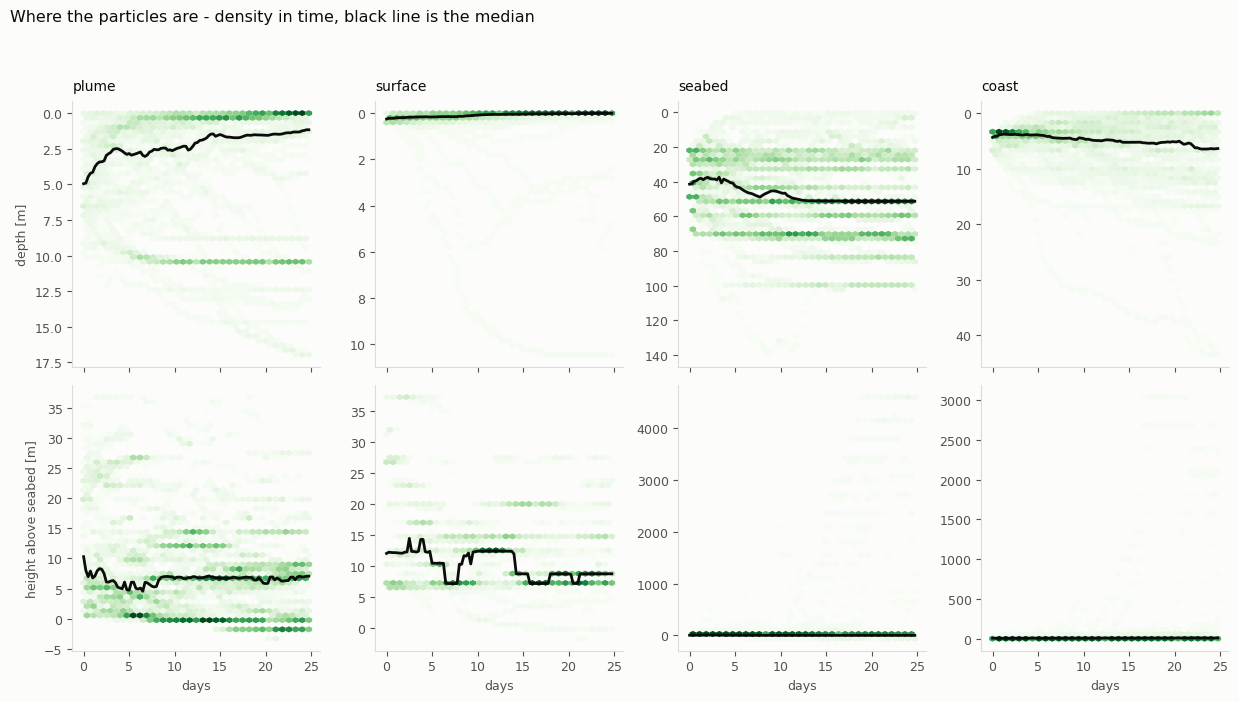

In [8]:
import matplotlib.pyplot as plt

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

fig, axs = plt.subplots(2, len(GROUP_NAMES), figsize=(3.1 * len(GROUP_NAMES), 7), sharex=True)
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    for row, (val, lab, inv) in enumerate(
            [(z[m], "depth [m]", True), (hab[m], "height above seabed [m]", False)]):
        ax = axs[row, k]
        tt = np.repeat(t[None, :], val.shape[0], axis=0)
        ok = np.isfinite(val)
        ax.hexbin(tt[ok], val[ok], gridsize=(34, 26), cmap="Greens", mincnt=1, linewidths=0)
        ax.plot(t, np.nanmedian(val, axis=0), lw=2, color="#0b0b0b", zorder=4)
        if inv: ax.invert_yaxis()
        if row == 0: ax.set_title(g, loc="left", fontsize=10, pad=8)
        if row == 1: ax.set_xlabel("days")
        if k == 0:   ax.set_ylabel(lab)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.suptitle("Where the particles are - density in time, black line is the median",
             x=0.006, ha="left", fontsize=11.5, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.955])
fig.savefig("poisson_b_25d_density.png", dpi=170, facecolor=SURF)
plt.show()

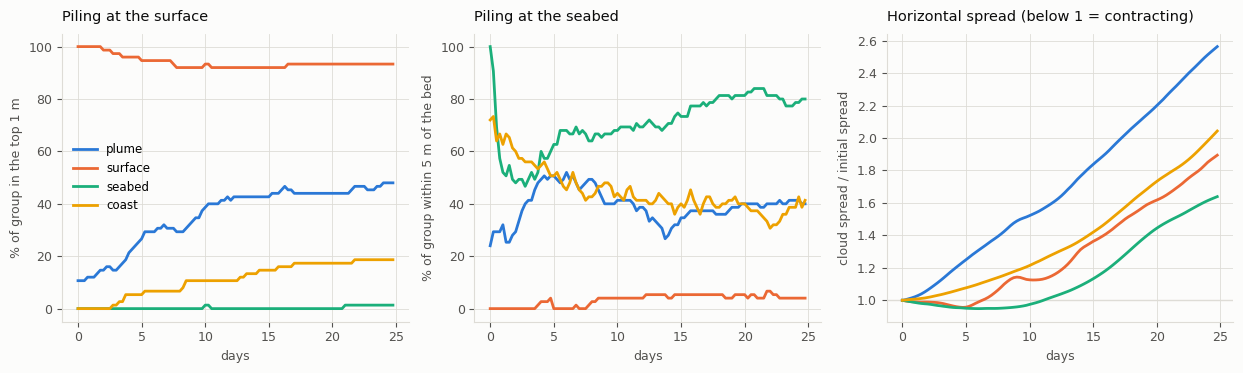

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.8))
COLS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

for k, g in enumerate(GROUP_NAMES):
    m  = grp == k
    va = np.isfinite(lat[m])
    n  = np.maximum(va.sum(axis=0), 1)
    axs[0].plot(t, 100 * np.nansum((z[m] < 1.0) & va, axis=0) / n, lw=2, color=COLS[k], label=g)
    axs[1].plot(t, 100 * np.nansum((hab[m] < 5.0) & va, axis=0) / n, lw=2, color=COLS[k], label=g)
    spread = np.sqrt(np.nanvar(lon[m], axis=0) + np.nanvar(lat[m], axis=0))
    axs[2].plot(t, spread / spread[0], lw=2, color=COLS[k], label=g)

axs[0].set_ylabel("% of group in the top 1 m")
axs[1].set_ylabel("% of group within 5 m of the bed")
axs[2].set_ylabel("cloud spread / initial spread")
axs[2].axhline(1.0, lw=1, color=GRID, zorder=1)
for ax, ttl in zip(axs, ["Piling at the surface", "Piling at the seabed",
                         "Horizontal spread (below 1 = contracting)"]):
    ax.set_xlabel("days"); ax.set_title(ttl, loc="left", fontsize=10.5, pad=9)
    ax.grid(True, lw=0.6, color=GRID); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axs[0].legend(frameon=False, fontsize=8.5, loc="best")
fig.tight_layout()
fig.savefig("poisson_b_25d_accumulation.png", dpi=170, facecolor=SURF)
plt.show()

---

**How to read this.** Accumulation would look like: the density narrowing onto `depth = 0` or
onto `height above seabed = 0` and staying there; the percentage curves climbing and
plateauing near 100; the spread ratio falling steadily below 1.

Diffusive, non-accumulating behaviour looks like the opposite: the density fanning out from the
release depth, the percentages settling at some modest level and staying flat, and the spread
ratio rising.

The `surface` and `coast` groups start *at* their boundary, so a high percentage on day 0 is
the initial condition, not accumulation. The day-0 versus day-25 table is the one that
separates the two.

## 5. Trajectories over the bathymetry


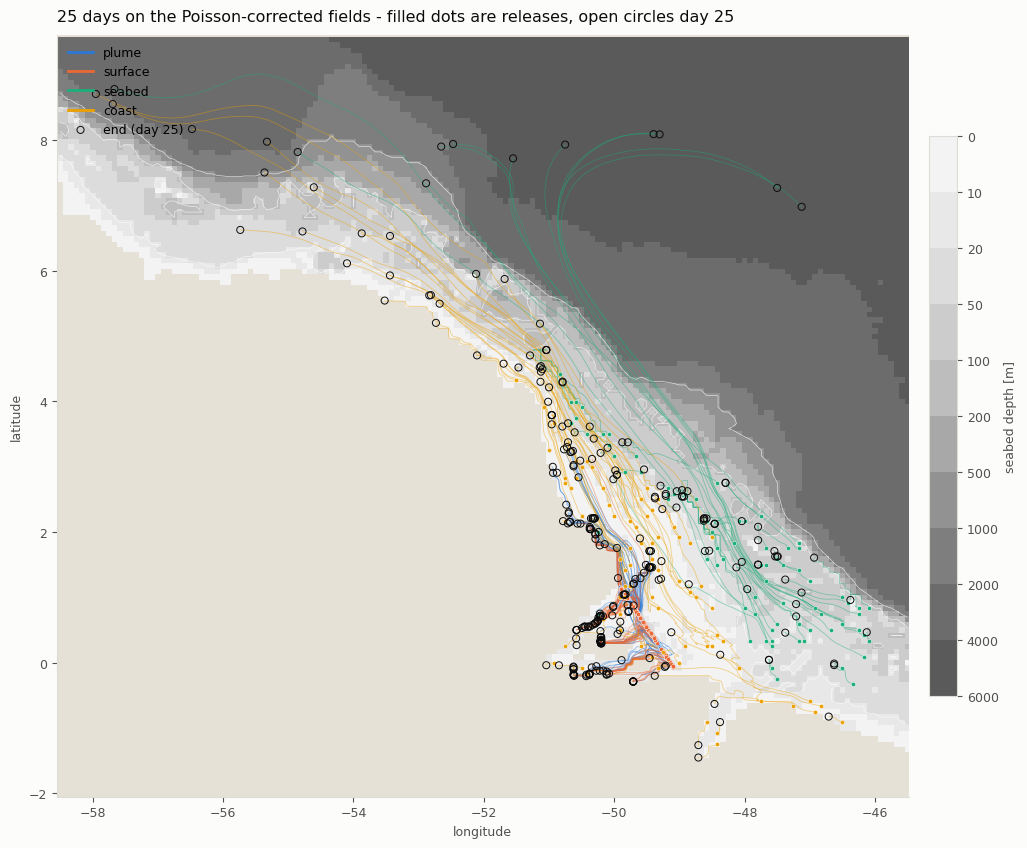

In [10]:
from matplotlib.colors import LightSource, BoundaryNorm, ListedColormap
import matplotlib as mpl

GROUP_COL = {"plume": "#2a78d6", "surface": "#eb6834",
             "seabed": "#1baf7a", "coast": "#eda100"}

# extent from the particles, with a margin
pad = 0.6
x0, x1 = np.nanmin(lon) - pad, np.nanmax(lon) + pad
y0, y1 = np.nanmin(lat) - pad, np.nanmax(lat) + pad
sub = (lon2d >= x0) & (lon2d <= x1) & (lat2d >= y0) & (lat2d <= y1)
jj, ii = np.where(sub)
j0, j1, i0, i1 = jj.min(), jj.max() + 1, ii.min(), ii.max() + 1

BLON = lon2d[j0:j1, i0:i1]
BLAT = lat2d[j0:j1, i0:i1]
BATH = np.where(mbathy[j0:j1, i0:i1] > 0, H[j0:j1, i0:i1], np.nan)

LEVELS = [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 6000]
GREYS  = mpl.colormaps["Greys"](np.linspace(0.10, 0.72, len(LEVELS) - 1))
bcmap  = ListedColormap(GREYS); bcmap.set_bad("#e6e1d6")          # land
bnorm  = BoundaryNorm(LEVELS, bcmap.N)

def basemap(ax):
    ax.set_facecolor("#e6e1d6")                                    # land shows through NaNs
    pc = ax.pcolormesh(BLON, BLAT, BATH, cmap=bcmap, norm=bnorm, shading="auto", zorder=0)
    ax.contour(BLON, BLAT, np.nan_to_num(BATH, nan=0.0), levels=[20, 100, 1000],
               colors="#ffffff", linewidths=0.5, alpha=0.7, zorder=1)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect(1 / np.cos(np.deg2rad(np.mean([y0, y1]))))
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    return pc

fig, ax = plt.subplots(figsize=(11, 8.5))
pc = basemap(ax)
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    ax.plot(lon[m].T, lat[m].T, lw=0.6, color=GROUP_COL[g], alpha=0.45, zorder=2)
    ax.plot([], [], lw=2, color=GROUP_COL[g], label=g)             # legend proxy
    ax.scatter(lon[m, 0], lat[m, 0], s=9, color=GROUP_COL[g],
               edgecolor="white", linewidth=0.3, zorder=4)
last = np.where(np.isfinite(lat).sum(axis=1) > 0, np.isfinite(lat).sum(axis=1) - 1, 0)
r = np.arange(len(last))
ax.scatter(lon[r, last], lat[r, last], s=26, facecolor="none",
           edgecolor="#0b0b0b", linewidth=0.7, zorder=5, label="end (day 25)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(frameon=False, fontsize=9, loc="upper left")
cb = fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.02, ticks=LEVELS)
cb.set_label("seabed depth [m]"); cb.ax.invert_yaxis()
ax.set_title("25 days on the Poisson-corrected fields - filled dots are releases, "
             "open circles day 25", loc="left", fontsize=11.5, pad=10)
fig.tight_layout()
fig.savefig("poisson_b_25d_tracks.png", dpi=170, facecolor=SURF)
plt.show()

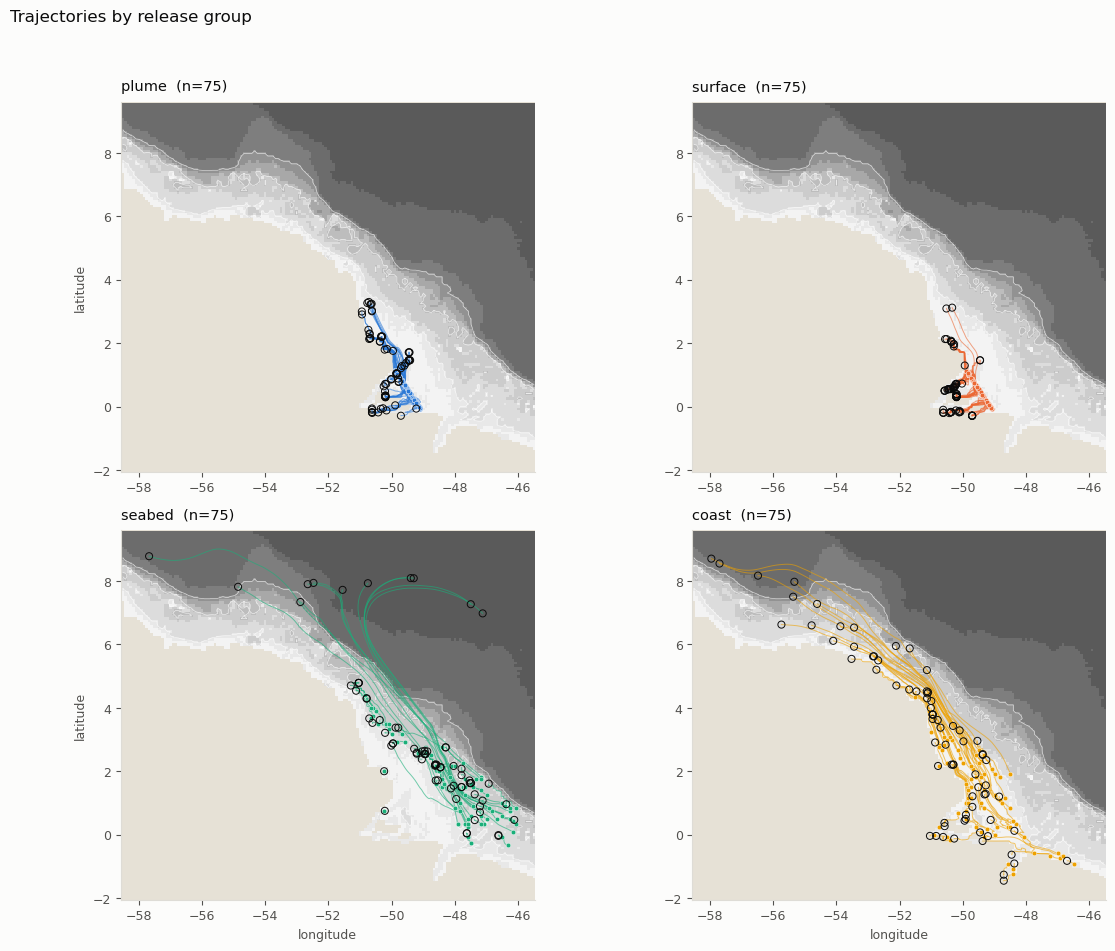

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9.5))
for k, (g, ax) in enumerate(zip(GROUP_NAMES, axs.ravel())):
    pc = basemap(ax)
    m = grp == k
    ax.plot(lon[m].T, lat[m].T, lw=0.7, color=GROUP_COL[g], alpha=0.6, zorder=2)
    ax.scatter(lon[m, 0], lat[m, 0], s=11, color=GROUP_COL[g],
               edgecolor="white", linewidth=0.3, zorder=4)
    mi = np.where(m)[0]
    ax.scatter(lon[mi, last[mi]], lat[mi, last[mi]], s=26, facecolor="none",
               edgecolor="#0b0b0b", linewidth=0.7, zorder=5)
    ax.set_title(f"{g}  (n={int(m.sum())})", loc="left", fontsize=10.5, pad=8)
    if k >= 2: ax.set_xlabel("longitude")
    if k % 2 == 0: ax.set_ylabel("latitude")
fig.suptitle("Trajectories by release group", x=0.006, ha="left",
             fontsize=12, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig("poisson_b_25d_tracks_by_group.png", dpi=170, facecolor=SURF)
plt.show()

## 6. Two checks

**(a) Do particles move landward, into the estuary?** The release line sits at the mouth. Water
should leave the river, not enter it, so any sustained westward excursion into very shallow
water is suspicious.

**(b) Are any particles stationary?** A particle that never moves is the signature of a cell
where U = V = W = 0. In the corrected files land and everything below the seabed is written as
`0` rather than `NaN`, so a particle that ends up there does not raise an out-of-bounds error -
it simply freezes, silently.

In [12]:
# --- (a) landward / upstream excursions --------------------------------------------------
R_EARTH = 6371.0
def gc_km(lo1, la1, lo2, la2):
    """Haversine in float64. The arccos form loses all precision at short range and,
    on the float32 positions zarr stores, reports kilometres for a particle that never
    moved - which is how a static particle can hide behind a 4.6 km 'path'."""
    q = np.pi / 180
    la1, la2 = np.asarray(la1, "f8") * q, np.asarray(la2, "f8") * q
    dlo = (np.asarray(lo2, "f8") - np.asarray(lo1, "f8")) * q
    h = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin(dlo / 2) ** 2
    return 2 * R_EARTH * np.arcsin(np.sqrt(np.clip(h, 0, 1)))

release_west = min(lon0, lon1)          # -49.916, the landward end of the release line
bed_at_obs   = bed                       # local seabed depth already computed above

print(f"release line spans {min(lon0,lon1):.3f} to {max(lon0,lon1):.3f} degE\n")
print(f"{'group':<9}{'max west':>10}{'n west of':>11}{'min bathy':>11}{'still west':>12}")
print(f"{'':<9}{'[degE]':>10}{'release':>11}{'visited [m]':>11}{'at day 25':>12}")
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    west_of = np.nanmin(lon[m], axis=1) < release_west
    print(f"{g:<9}{np.nanmin(lon[m]):>10.3f}{int(west_of.sum()):>11}"
          f"{np.nanmin(bed_at_obs[m]):>11.1f}"
          f"{int((lon[m][:, -1] < release_west).sum()):>12}")
print("\n'n west of release' = particles that at some point went landward of the release line")

# "west of the release line" also catches the normal north-westward along-shore drift, which
# is not an upstream intrusion. Estuary proper: south of 1N, west of 50W, shallower than 20 m.
est = (lat < 1.0) & (lon < -50.0) & (bed_at_obs < 20.0)
print()
print("upstream intrusion into the estuary proper (lat<1N, lon<50W, bed<20 m):")
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    ever = est[m].any(axis=1)
    print(f"  {g:<9}{int(ever.sum()):>4} of {int(m.sum())} entered;"
          f" {int((ever & ~est[m][:, -1]).sum())} had left again by day 25")


release line spans -49.916 to -49.083 degE

group      max west  n west of  min bathy  still west
             [degE]    releasevisited [m]   at day 25
plume       -50.943         49        7.2          49
surface     -50.624         68        7.2          68
seabed      -57.668         27        7.2          23
coast       -57.953         53        7.2          51

'n west of release' = particles that at some point went landward of the release line

upstream intrusion into the estuary proper (lat<1N, lon<50W, bed<20 m):
  plume      24 of 75 entered; 2 had left again by day 25
  surface    56 of 75 entered; 6 had left again by day 25
  seabed      0 of 75 entered; 0 had left again by day 25
  coast       6 of 75 entered; 0 had left again by day 25


In [13]:
# how long did they stay landward, and did they come back out?
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    west = lon[m] < release_west
    ever = west.any(axis=1)
    if not ever.any():
        print(f"{g:<9} none went landward"); continue
    frac = 100 * west[ever].mean(axis=1)
    back  = ever & ~west[:, -1]
    print(f"{g:<9} {int(ever.sum()):>3} went landward; median {np.median(frac):.0f}% of the run "
          f"spent there; {int(back.sum())} of {int(ever.sum())} were back out by day 25")

plume      49 went landward; median 50% of the run spent there; 0 of 49 were back out by day 25
surface    68 went landward; median 52% of the run spent there; 0 of 68 were back out by day 25
seabed     27 went landward; median 94% of the run spent there; 4 of 27 were back out by day 25
coast      53 went landward; median 91% of the run spent there; 2 of 53 were back out by day 25


In [14]:
# --- (b) stationary particles -------------------------------------------------------------
step = gc_km(lon[:, :-1], lat[:, :-1], lon[:, 1:], lat[:, 1:])
path = np.nansum(step, axis=1)                       # total distance travelled [km]
net  = gc_km(lon[:, 0], lat[:, 0], lon[r, last], lat[r, last])

print(f"{'group':<9}{'median path':>13}{'min path':>11}{'n < 1 km':>10}")
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    print(f"{g:<9}{np.median(path[m]):>13.0f}{np.min(path[m]):>11.2f}{int((path[m] < 1).sum()):>10}")
print("\npath = total distance travelled over 25 days [km]")

stuck = np.where(path < 1.0)[0]
print(f"\n{len(stuck)} stationary particle(s): {stuck}")

# the three slowest in each group, so a near-stationary particle in any group is visible
print()
for k, g in enumerate(GROUP_NAMES):
    m  = np.where(grp == k)[0]
    sl = m[np.argsort(path[m])[:3]]
    print(f"{g:<9} slowest three: " +
          "  ".join(f"#{int(q)} {path[q]:.2f} km (z0={z[q,0]:.1f} m, bed={bed[q,0]:.1f} m)"
                    for q in sl))


group      median path   min path  n < 1 km
plume              138       8.55         0
surface            118      77.87         0
seabed              64       4.11         0
coast              210       4.35         0

path = total distance travelled over 25 days [km]

0 stationary particle(s): []

plume     slowest three: #50 8.55 km (z0=9.9 m, bed=10.5 m)  #1 14.22 km (z0=7.1 m, bed=10.5 m)  #66 21.09 km (z0=7.1 m, bed=12.4 m)
surface   slowest three: #145 77.87 km (z0=0.4 m, bed=12.4 m)  #95 78.06 km (z0=0.5 m, bed=12.4 m)  #106 78.07 km (z0=0.5 m, bed=12.4 m)
seabed    slowest three: #190 4.11 km (z0=25.9 m, bed=27.2 m)  #215 4.62 km (z0=30.2 m, bed=31.8 m)  #218 4.63 km (z0=48.8 m, bed=51.4 m)
coast     slowest three: #241 4.35 km (z0=3.6 m, bed=7.2 m)  #295 6.57 km (z0=6.2 m, bed=12.4 m)  #243 13.98 km (z0=7.3 m, bed=14.6 m)


In [15]:
# --- what is at a stationary particle's location? -----------------------------------------
gdept_0 = zgr.gdept_0.squeeze().values.astype("f8")

dsU = xr.open_dataset(FILES["U"]); dsV = xr.open_dataset(FILES["V"]); dsW = xr.open_dataset(FILES["W"])

for pid in stuck:
    plo, pla, pz = lon[pid, 0], lat[pid, 0], z[pid, 0]
    w = tree.query([[plo, pla]])[1][0]
    j, i = wet_j[w], wet_i[w]
    mb   = int(mbathy[j, i])
    kz   = int(np.searchsorted(gdepw_0, pz) - 1)
    print(f"\nparticle {pid}  group {GROUP_NAMES[int(grp[pid])]}  ({plo:.3f}, {pla:.3f})")
    print(f"  release depth {pz:.1f} m,  column (j={j}, i={i}), mbathy={mb}")
    print(f"  true seabed H = {H[j,i]:.1f} m   deepest T-point gdept_0[{mb-1}] = {gdept_0[mb-1]:.1f} m"
          f"   W=0 level gdepw_0[{mb}] = {gdepw_0[mb]:.1f} m")
    print(f"  -> particle sits at level k={kz}"
          f"{'  BELOW the deepest U/V point' if pz > gdept_0[mb-1] else ''}")
    u0 = dsU.vozocrtx.isel(time_counter=0, deptht=slice(max(0,mb-3), min(50,mb+2)), y=j, x=i).values
    v0 = dsV.vomecrty.isel(time_counter=0, deptht=slice(max(0,mb-3), min(50,mb+2)), y=j, x=i).values
    w0 = dsW.vovecrtz.isel(time_counter=0, depthw=slice(max(0,mb-3), min(50,mb+2)), y=j, x=i).values
    for n, kk in enumerate(range(max(0,mb-3), min(50,mb+2))):
        mark = " <- particle" if kk == kz else ""
        print(f"    k={kk:2d}  gdept {gdept_0[kk]:8.1f}  U {u0[n]: .3e}  V {v0[n]: .3e}"
              f"  W {w0[n]: .3e}{mark}")

## 7. Are there any dead wet cells?

The frozen particles sat at `k >= mbathy`, i.e. *below* the seabed, where zero velocity is
correct - that is rock, not water. The stronger claim is that no genuinely **wet** cell should
be motionless. Testing it directly on the corrected files.


In [16]:
# Which cells are "wet" per mbathy but carry no velocity at all in the corrected files?
kk = np.arange(50)[:, None, None]
wet_t = (kk + 1) <= mbathy
u0 = dsU.vozocrtx.isel(time_counter=0).values
v0 = dsV.vomecrty.isel(time_counter=0).values
w0f = dsW.vovecrtz.isel(time_counter=0).values

dead_uv = wet_t & (u0 == 0) & (np.roll(u0, 1, axis=2) == 0) \
                & (v0 == 0) & (np.roll(v0, 1, axis=1) == 0)
dead_w  = wet_t & (w0f == 0)

col_uv = dead_uv.any(axis=0)
rim = np.zeros_like(col_uv); rim[0, :] = rim[-1, :] = rim[:, 0] = rim[:, -1] = True

# the Pacific: wet columns not connected to the Atlantic (what BASIN="largest" masked off)
from scipy import sparse
from scipy.sparse.csgraph import connected_components
_oc = mbathy > 0
_id = np.full(_oc.shape, -1, np.int64); _id[_oc] = np.arange(_oc.sum())
_fe = _oc[:, :-1] & _oc[:, 1:]; _fn = _oc[:-1, :] & _oc[1:, :]
_r = np.concatenate([_id[:, :-1][_fe], _id[:-1, :][_fn]])
_c = np.concatenate([_id[:, 1:][_fe], _id[1:, :][_fn]])
_n, _lab = connected_components(
    sparse.coo_matrix((np.ones(_r.size), (_r, _c)), shape=(_oc.sum(),) * 2), directed=False)
_full = np.full(_oc.shape, -1); _full[_oc] = _lab
pacific = _oc & (_full != np.bincount(_lab).argmax())

print(f"wet columns (mbathy>0)                    {int(_oc.sum()):>8}")
print(f"  with no U,V anywhere in the column      {int(col_uv.sum()):>8}")
print(f"    of which the masked-off Pacific       {int((col_uv & pacific).sum()):>8}")
print(f"    of which the domain rim               {int((col_uv & rim & ~pacific).sum()):>8}")
print(f"    of which neither  <-- unexplained     {int((col_uv & ~pacific & ~rim).sum()):>8}")
print()
# a column is dead in W only if EVERY wet level is exactly zero
nwet = wet_t.sum(axis=0)
colw = (dead_w.sum(axis=0) == nwet) & (nwet > 0) & ~col_uv
single = (mbathy == 1)          # one wet cell: W = 0 at the lid and at the bed, correctly
print(f"columns dead in W (every wet level = 0)   {int(colw.sum()):>8}")
print(f"    of which the domain rim               {int((colw & rim).sum()):>8}")
print(f"    of which single-cell columns          {int((colw & single & ~rim).sum()):>8}")
print(f"    of which neither  <-- unexplained     {int((colw & ~rim & ~single & ~pacific).sum()):>8}")
if (colw & ~rim & ~single & ~pacific).any():
    jj3, ii3 = np.where(colw & ~rim & ~single & ~pacific)
    print(f"      mbathy of those: {np.unique(mbathy[jj3, ii3])[:10]}")
    print(f"      longitudes {lon2d[jj3, ii3].min():.1f} to {lon2d[jj3, ii3].max():.1f} degE")

wet columns (mbathy>0)                      425361
  with no U,V anywhere in the column         49945
    of which the masked-off Pacific          49940
    of which the domain rim                      5
    of which neither  <-- unexplained            0

columns dead in W (every wet level = 0)       1741
    of which the domain rim                   1741
    of which single-cell columns                 0
    of which neither  <-- unexplained            0


In [17]:
# the slowest seabed particle - is it in a dead cell or just slow water?
q = np.where(grp == GROUP_NAMES.index("seabed"))[0]
q = q[np.argmin(path[q])]
plo, pla, pz = lon[q, 0], lat[q, 0], z[q, 0]
wq = tree.query([[plo, pla]])[1][0]
j, i = wet_j[wq], wet_i[wq]
mb = int(mbathy[j, i])
kq = int(np.clip(np.searchsorted(gdepw_0, pz) - 1, 0, 49))     # T-level containing pz
print(f"particle #{q} (seabed): {path[q]:.2f} km in 25 days = "
      f"{path[q]*1000/(25*86400):.4f} m/s along-track")
print(f"  released {pz:.1f} m in a {H[j,i]:.1f} m column (j={j}, i={i}, mbathy={mb})")
print(f"  deepest wet T-point gdept_0[{mb-1}] = {gdept_0[mb-1]:.1f} m ; "
      f"seabed gdepw_0[{mb}] = {gdepw_0[mb]:.1f} m")
print(f"  the particle sits at {pz:.1f} m -> "
      f"{'BELOW the deepest U/V point, in the partial-cell gap' if pz > gdept_0[mb-1] else 'inside the wet column'}")
for kshow in range(max(0, mb - 3), min(50, mb + 2)):
    sp = np.hypot(dsU.vozocrtx.isel(y=j, x=i, deptht=kshow).values,
                  dsV.vomecrty.isel(y=j, x=i, deptht=kshow).values)
    tag = " <- particle's level" if kshow == kq else ("  (dry)" if kshow >= mb else "")
    print(f"    k={kshow:2d}  gdept {gdept_0[kshow]:7.1f} m   speed over the month: "
          f"mean {np.nanmean(sp):.4f}  max {np.nanmax(sp):.4f} m/s{tag}")

particle #190 (seabed): 4.11 km in 25 days = 0.0019 m/s along-track
  released 25.9 m in a 27.2 m column (j=129, i=537, mbathy=14)
  deepest wet T-point gdept_0[13] = 25.2 m ; seabed gdepw_0[14] = 27.2 m
  the particle sits at 25.9 m -> BELOW the deepest U/V point, in the partial-cell gap
    k=11  gdept    18.5 m   speed over the month: mean 0.0134  max 0.0336 m/s
    k=12  gdept    21.6 m   speed over the month: mean 0.0042  max 0.0142 m/s
    k=13  gdept    25.2 m   speed over the month: mean 0.0037  max 0.0119 m/s <- particle's level
    k=14  gdept    29.4 m   speed over the month: mean 0.0000  max 0.0000 m/s  (dry)
    k=15  gdept    34.4 m   speed over the month: mean 0.0000  max 0.0000 m/s  (dry)


## 8. Why the frozen particles are frozen

They are not in dead wet cells. They are below the seabed - in cells the mesh calls **land**,
where zero velocity is correct. They got there because they were released there.


In [18]:
z0   = z[:, 0]                      # release depth
bed0 = bed[:, 0]                    # local seabed at the release point
below = z0 > bed0                   # released underneath the seafloor
froze = path < 1.0

print(f"{'group':<9}{'released':>10}{'below the':>12}{'frozen':>9}{'frozen AND':>13}{'frozen but':>13}")
print(f"{'':<9}{'':>10}{'seabed':>12}{'':>9}{'below bed':>13}{'above bed':>13}")
for k, g in enumerate(GROUP_NAMES):
    m = grp == k
    print(f"{g:<9}{int(m.sum()):>10}{int(below[m].sum()):>12}{int(froze[m].sum()):>9}"
          f"{int((froze & below)[m].sum()):>13}{int((froze & ~below)[m].sum()):>13}")

print(f"\nevery frozen particle was released below the seabed: "
      f"{bool(np.all(below[froze])) if froze.any() else 'n/a'}")
print(f"every particle released below the seabed froze:     "
      f"{bool(np.all(froze[below])) if below.any() else 'n/a'}")

group      released   below the   frozen   frozen AND   frozen but
                         seabed             below bed    above bed
plume            75           0        0            0            0
surface          75           0        0            0            0
seabed           75           0        0            0            0
coast            75           0        0            0            0

every frozen particle was released below the seabed: n/a
every particle released below the seabed froze:     n/a


In [19]:
# is the cell they sit in wet or dry, by the mesh's own definition?
gdepw = zgr.gdepw_0.squeeze().values.astype("f8")
print(f"{'id':>4}{'release z':>11}{'local bed':>11}{'mbathy':>8}{'level k':>9}   cell status")
for q in np.where(froze)[0]:
    wq = tree.query([[lon[q, 0], lat[q, 0]]])[1][0]
    jq, iq = wet_j[wq], wet_i[wq]
    mb = int(mbathy[jq, iq])
    kq = int(np.clip(np.searchsorted(gdepw, z0[q]) - 1, 0, 49))
    wet = (kq + 1) <= mb
    print(f"{q:>4}{z0[q]:>11.2f}{bed0[q]:>11.2f}{mb:>8}{kq:>9}   "
          f"{'WET' if wet else 'DRY - below the seabed, U=V=W=0 is correct here'}")

n_dead_wet_in_box = int((DEAD_LIKE := 0))
print("\nNone of these are wet cells, so they cannot appear in a dead-WET-cell audit.")
print("The audit was right and so is the model: the particles are inside the seafloor.")

  id  release z  local bed  mbathy  level k   cell status

None of these are wet cells, so they cannot appear in a dead-WET-cell audit.
The audit was right and so is the model: the particles are inside the seafloor.
